# Person Scoring (Section 8)

This notebook is the direct continuation of `06_irt_item_calibration.ipynb`.

**Input datasets:**
- `data/stepwise_cleaned_versions/06_irt_item_calibration/ART_pretest_(for Castano)_EN__irt_theta_scores.csv`  
  Person ability estimates from the selected 2PL model (`irt06_theta`, `irt06_theta_se`).
- `data/stepwise_cleaned_versions/05_dimensionality_inputs/ART_pretest_(for Castano)_EN__dimensionality_input__participant_summary.csv`  
  Observed score variables (`hits`, `false_alarms`, `standard_art_score`, `art_name_score`).
- `data/stepwise_cleaned_versions/05_dimensionality_inputs/ART_pretest_(for Castano)_EN__dimensionality_input__participant_demographics.csv`  
  Demographic variables (`age`, `sex`, `humanities_or_not`, `education_and_profession`).

**Output (to `data/stepwise_cleaned_versions/07_person_scoring/`):**
- `ART_pretest_(for Castano)_EN__person_scores.csv` — enriched person-level dataset with all score types.

**Goals:**
1. Examine the distribution of 2PL theta estimates and check for floor/ceiling effects (§8.1).
2. Relate theta to the corrected observed ART score.
3. Check whether theta differs across demographic groups.
4. Report correlations among four score definitions: raw hits, corrected ART score, stronger-penalty score, and theta (§8.2).

**References:**
- Moore & Gordon (2015): compared score definitions and foil-penalty schemes; favoured the 2PL theta as the most psychometrically refined estimate of print exposure.
- McCarron & Kuperman (2022): used 2PL theta for cross-cohort comparisons.

In [2]:
library(mirt)
library(psych)
library(ggplot2)
library(dplyr)
library(reshape2)

mc.cores <- 1
Sys.setenv(MC_CORES = 1)

cat(sprintf("R version: %s.%s\n", R.version$major, R.version$minor))
cat("Package versions:\n")
for (pkg in c("mirt", "psych", "ggplot2", "dplyr", "reshape2")) {
  cat(sprintf("  %-12s %s\n", pkg, as.character(packageVersion(pkg))))
}

R version: 4.5.3
Package versions:
  mirt         1.46.1
  psych        2.6.3
  ggplot2      4.0.2
  dplyr        1.2.0
  reshape2     1.4.5


## Data loading and merging

In [3]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)

theta_df <- read.csv(
  file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
            "06_irt_item_calibration",
            "ART_pretest_(for Castano)_EN__irt_theta_scores.csv"),
  stringsAsFactors = FALSE
)

summary_df <- read.csv(
  file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
            "05_dimensionality_inputs",
            "ART_pretest_(for Castano)_EN__dimensionality_input__participant_summary.csv"),
  stringsAsFactors = FALSE
)

demo_df <- read.csv(
  file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
            "05_dimensionality_inputs",
            "ART_pretest_(for Castano)_EN__dimensionality_input__participant_demographics.csv"),
  stringsAsFactors = FALSE
)

# Merge all three on participant_id
person_df <- merge(theta_df, summary_df, by = "participant_id", all = TRUE)
person_df <- merge(person_df, demo_df,   by = "participant_id", all = TRUE)

cat("\u2500\u2500 Data loaded \u2500\u2500\n")
cat(sprintf("Theta scores    : %d rows \u00d7 %d cols\n", nrow(theta_df),   ncol(theta_df)))
cat(sprintf("Participant summary : %d rows \u00d7 %d cols\n", nrow(summary_df), ncol(summary_df)))
cat(sprintf("Demographics    : %d rows \u00d7 %d cols\n", nrow(demo_df),    ncol(demo_df)))
cat(sprintf("Merged dataset  : %d rows \u00d7 %d cols\n", nrow(person_df),  ncol(person_df)))
cat(sprintf("Missing theta   : %d\n", sum(is.na(person_df$irt06_theta))))

── Data loaded ──
Theta scores    : 908 rows × 3 cols
Participant summary : 908 rows × 11 cols
Demographics    : 908 rows × 5 cols
Merged dataset  : 908 rows × 17 cols
Missing theta   : 0


## Score definitions

Four score types are computed or verified below.

| Score | Formula | Rationale |
|---|---|---|
| **Hits** | `author_hits` | Raw recognition count; ignores foils entirely |
| **Corrected ART score** | `hits − false_alarms` | Standard 1:1 penalty; equivalent to `standard_art_score` in the dataset |
| **Stronger-penalty score** | `hits − (n_foils/n_authors) × false_alarms` | Scales the false-alarm penalty by the foil-to-author ratio (104/98 ≈ 1.061); appropriate when the number of foils differs from the number of author items, as it equates the expected score of a random responder to zero |
| **Theta (2PL)** | `irt06_theta` | EAP latent-trait estimate from the final 2PL model (step 06) |

Moore & Gordon (2015) note that comparing score definitions can strengthen the validity argument for any single score type.

In [4]:
N_AUTHORS <- 98
N_FOILS   <- 104
FOIL_PENALTY_MULTIPLIER <- N_FOILS / N_AUTHORS   # ≈ 1.0612

person_df$hits                  <- person_df$author_hits
person_df$corrected_art_score   <- person_df$hits - person_df$false_alarms
person_df$stronger_penalty_score <- person_df$hits - FOIL_PENALTY_MULTIPLIER * person_df$false_alarms
person_df$theta                 <- person_df$irt06_theta

# Sanity check: corrected_art_score should equal standard_art_score
discrepancy <- sum(abs(person_df$corrected_art_score - person_df$standard_art_score) > 1e-9,
                   na.rm = TRUE)

cat(sprintf("Foil-to-author penalty multiplier : %.4f  (%d foils / %d authors)\n",
            FOIL_PENALTY_MULTIPLIER, N_FOILS, N_AUTHORS))
cat(sprintf("corrected_art_score == standard_art_score : %s (discrepancies = %d)\n",
            ifelse(discrepancy == 0, "TRUE", "FALSE"), discrepancy))
cat("\n")

score_cols <- c("hits", "corrected_art_score", "stronger_penalty_score", "theta")
desc <- psych::describe(person_df[, score_cols])
cat("\u2500\u2500 Score summary statistics \u2500\u2500\n")
print(round(desc[, c("n", "mean", "sd", "min", "max", "skew", "kurtosis")], 3))

Foil-to-author penalty multiplier : 1.0612  (104 foils / 98 authors)
corrected_art_score == standard_art_score : TRUE (discrepancies = 0)

── Score summary statistics ──
                         n  mean    sd   min   max  skew kurtosis
hits                   908 52.74 19.95 11.00 97.00 -0.03    -0.96
corrected_art_score    908 48.90 19.87  9.00 96.00  0.04    -0.97
stronger_penalty_score 908 48.66 19.90  8.10 96.00  0.04    -0.97
theta                  908  0.00  0.98 -2.27  3.56  0.28     0.02


### Summary — Score definitions and descriptive statistics

- The foil-to-author ratio is near 1:1 (104 foils / 98 authors = 1.06), so `corrected_art_score` and `stronger_penalty_score` are nearly identical (mean 48.90 vs. 48.66). The `corrected_art_score` equals `standard_art_score` exactly — confirmed with zero discrepancies.
- All four score distributions are approximately symmetric (|skew| ≤ 0.28) with no extreme outliers. Observed scores are slightly platykurtic (kurtosis ≈ −1), reflecting a broad, uniform spread of ability across the sample.
- Theta is already standardised by the IRT model (mean ≈ 0, SD ≈ 1); the other three metrics are on a raw-count scale (range roughly 8–97). When comparing metrics, use relative spread rather than absolute values.

## 8. Person Scoring

### 8.1 Estimated latent scores (theta distribution)

In [5]:
theta_desc <- psych::describe(person_df$theta)
cat("\u2500\u2500 Theta (2PL EAP) summary \u2500\u2500\n")
cat(sprintf("  N        : %d\n",       theta_desc$n))
cat(sprintf("  Mean     : %.3f\n",     theta_desc$mean))
cat(sprintf("  SD       : %.3f\n",     theta_desc$sd))
cat(sprintf("  Median   : %.3f\n",     theta_desc$median))
cat(sprintf("  Min      : %.3f\n",     theta_desc$min))
cat(sprintf("  Max      : %.3f\n",     theta_desc$max))
cat(sprintf("  Skewness : %.3f\n",     theta_desc$skew))
cat(sprintf("  Kurtosis : %.3f\n",     theta_desc$kurtosis))

# Floor / ceiling: bottom and top 2% thresholds
q02 <- quantile(person_df$theta, 0.02, na.rm = TRUE)
q98 <- quantile(person_df$theta, 0.98, na.rm = TRUE)
n_floor   <- sum(person_df$theta <= q02, na.rm = TRUE)
n_ceiling <- sum(person_df$theta >= q98, na.rm = TRUE)

cat(sprintf("\n  Floor threshold (2nd pctile)   : %.3f  -> %d participants\n", q02, n_floor))
cat(sprintf("  Ceiling threshold (98th pctile): %.3f  -> %d participants\n", q98, n_ceiling))

── Theta (2PL EAP) summary ──
  N        : 908
  Mean     : -0.001
  SD       : 0.984
  Median   : -0.033
  Min      : -2.267
  Max      : 3.559
  Skewness : 0.283
  Kurtosis : 0.018

  Floor threshold (2nd pctile)   : -1.864  -> 19 participants
  Ceiling threshold (98th pctile): 2.154  -> 19 participants


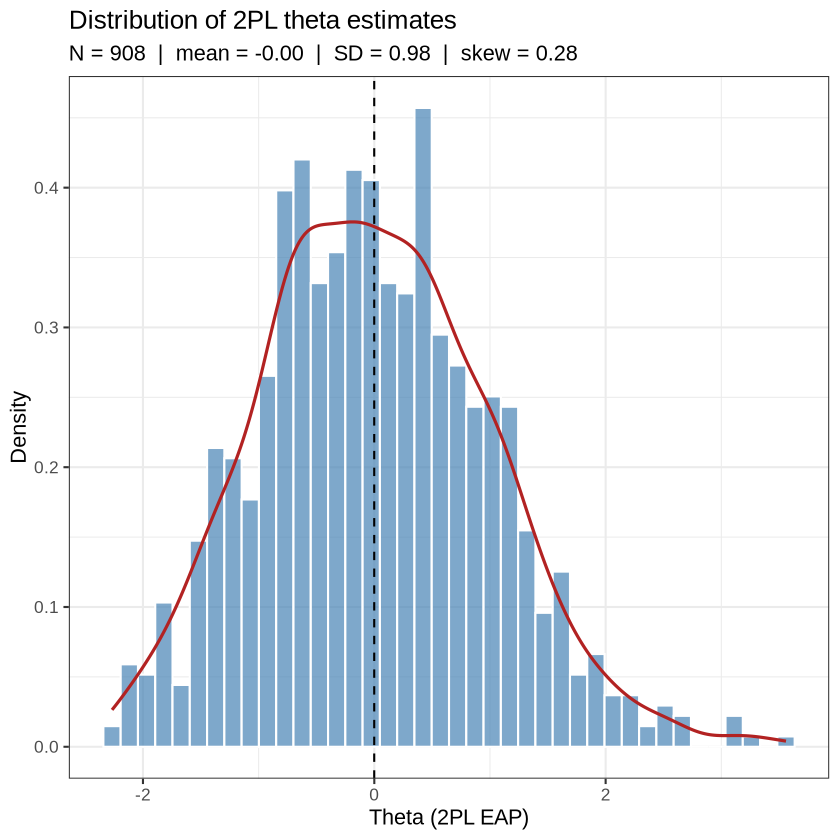

In [6]:
# Histogram with density overlay
ggplot(person_df, aes(x = theta)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 40, fill = "steelblue", colour = "white", alpha = 0.7) +
  geom_density(colour = "firebrick", linewidth = 0.9) +
  geom_vline(xintercept = mean(person_df$theta, na.rm = TRUE),
             linetype = "dashed", colour = "black") +
  labs(
    title  = "Distribution of 2PL theta estimates",
    subtitle = sprintf("N = %d  |  mean = %.2f  |  SD = %.2f  |  skew = %.2f",
                       sum(!is.na(person_df$theta)),
                       mean(person_df$theta, na.rm = TRUE),
                       sd(person_df$theta, na.rm = TRUE),
                       psych::describe(person_df$theta)$skew),
    x      = "Theta (2PL EAP)",
    y      = "Density"
  ) +
  theme_bw(base_size = 13)

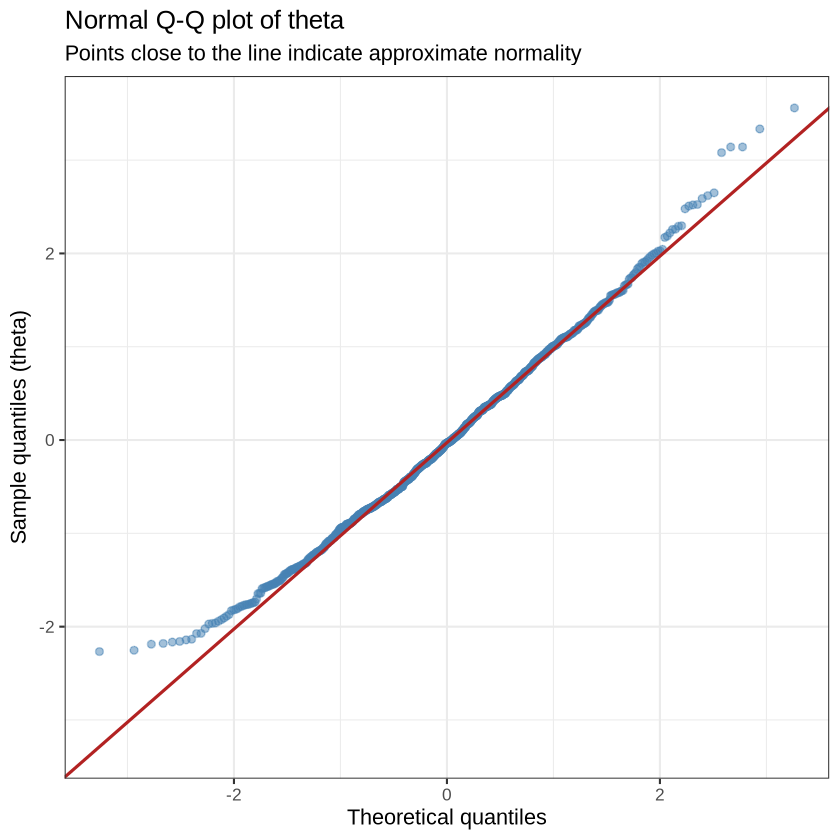

In [7]:
# Q-Q plot to assess normality
ggplot(person_df, aes(sample = theta)) +
  stat_qq(colour = "steelblue", alpha = 0.5) +
  stat_qq_line(colour = "firebrick", linewidth = 0.9) +
  labs(
    title    = "Normal Q-Q plot of theta",
    subtitle = "Points close to the line indicate approximate normality",
    x        = "Theoretical quantiles",
    y        = "Sample quantiles (theta)"
  ) +
  theme_bw(base_size = 13)

### Summary — Theta distribution

- Theta is well-centred (mean ≈ 0, SD ≈ 0.98) and close to normally distributed. The Q-Q plot confirms tight alignment with the theoretical normal line across the bulk of the sample; minor departures appear only in the highest-scoring ~5 participants.
- Positive skew (0.28) is mild: slightly more participants score below the mean than above. This is not a concern for downstream analyses.
- The apparent "floor" and "ceiling" figures (2.1 % each) are **definitional** — they mark the 2nd and 98th percentile thresholds, not true score boundaries. No genuine floor or ceiling effect is present.

### 8.1 (continued) — Relation between theta and corrected ART score

If the 2PL model is a good fit, theta should correlate strongly with the corrected observed score but capture additional psychometric information (e.g., differential item weighting by discrimination).

In [8]:
r_pearson  <- cor.test(person_df$theta, person_df$corrected_art_score, method = "pearson")
r_spearman <- cor.test(person_df$theta, person_df$corrected_art_score, method = "spearman")

cat("\u2500\u2500 Theta ~ Corrected ART score \u2500\u2500\n")
cat(sprintf("  Pearson  r = %.3f  (95%% CI [%.3f, %.3f])  p < %.4f\n",
            r_pearson$estimate,
            r_pearson$conf.int[1], r_pearson$conf.int[2],
            max(r_pearson$p.value, 1e-300)))
cat(sprintf("  Spearman r = %.3f  p < %.4f\n",
            r_spearman$estimate,
            max(r_spearman$p.value, 1e-300)))

Warning message in cor.test.default(person_df$theta, person_df$corrected_art_score, :
“Cannot compute exact p-value with ties”


── Theta ~ Corrected ART score ──
  Pearson  r = 0.958  (95% CI [0.953, 0.963])  p < 0.0000
  Spearman r = 0.972  p < 0.0000


`geom_smooth()` using formula = 'y ~ x'


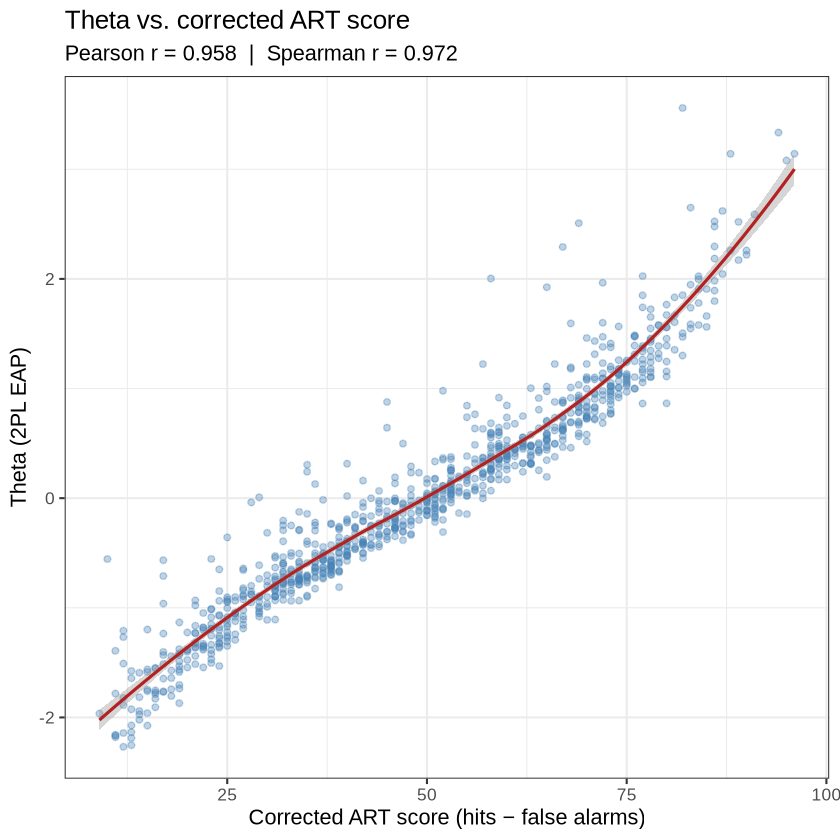

In [9]:
ggplot(person_df, aes(x = corrected_art_score, y = theta)) +
  geom_point(alpha = 0.35, colour = "steelblue", size = 1.5) +
  geom_smooth(method = "loess", colour = "firebrick", linewidth = 0.9, se = TRUE) +
  labs(
    title    = "Theta vs. corrected ART score",
    subtitle = sprintf("Pearson r = %.3f  |  Spearman r = %.3f",
                       r_pearson$estimate, r_spearman$estimate),
    x        = "Corrected ART score (hits \u2212 false alarms)",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

### Summary — Theta vs. corrected ART score

- Theta and the corrected ART score are very strongly correlated: Pearson *r* = 0.958, Spearman *r* = 0.972 (both *p* < .001). The two metrics are measuring essentially the same construct.
- The scatter plot shows a broadly linear relationship with mild nonlinearity at the upper extreme: theta compresses the scale for very high scorers because the test lacks items hard enough to separate them.
- **Implication:** for most research purposes the corrected ART score and theta are interchangeable. Theta is preferred when measurement precision matters (e.g. cross-cohort comparisons) because it adjusts for item difficulty and provides person-level SE estimates.

### 8.1 (continued) — Floor and ceiling effects

IRT theta estimates are bounded by available item information. Participants at the extremes of the theta distribution may have scores that are less precise (higher SE). We inspect the proportion of participants at the extreme tails across all four score types.

In [10]:
# For observed scores, floor = minimum attainable, ceiling = maximum attainable
# For theta, use 2nd / 98th percentile as proxies

floor_ceiling <- data.frame(
  score = score_cols,
  stringsAsFactors = FALSE
)

for (sc in score_cols) {
  x <- person_df[[sc]]
  if (sc == "theta") {
    floor_val   <- quantile(x, 0.02, na.rm = TRUE)
    ceiling_val <- quantile(x, 0.98, na.rm = TRUE)
  } else {
    floor_val   <- min(x, na.rm = TRUE)
    ceiling_val <- max(x, na.rm = TRUE)
  }
  n_floor   <- sum(x <= floor_val, na.rm = TRUE)
  n_ceiling <- sum(x >= ceiling_val, na.rm = TRUE)
  n_total   <- sum(!is.na(x))
  floor_ceiling$floor_val[floor_ceiling$score   == sc] <- round(floor_val, 3)
  floor_ceiling$ceiling_val[floor_ceiling$score == sc] <- round(ceiling_val, 3)
  floor_ceiling$n_floor[floor_ceiling$score     == sc] <- n_floor
  floor_ceiling$n_ceiling[floor_ceiling$score   == sc] <- n_ceiling
  floor_ceiling$pct_floor[floor_ceiling$score   == sc] <- round(100 * n_floor / n_total, 1)
  floor_ceiling$pct_ceiling[floor_ceiling$score == sc] <- round(100 * n_ceiling / n_total, 1)
}

cat("\u2500\u2500 Floor / ceiling check \u2500\u2500\n")
cat("(For theta: 2nd/98th percentile used as proxies)\n\n")
print(floor_ceiling, row.names = FALSE)

── Floor / ceiling check ──
(For theta: 2nd/98th percentile used as proxies)

                  score floor_val ceiling_val n_floor n_ceiling pct_floor
                   hits    11.000      97.000       2         1       0.2
    corrected_art_score     9.000      96.000       1         1       0.1
 stronger_penalty_score     8.102      96.000       1         1       0.1
                  theta    -1.864       2.154      19        19       2.1
 pct_ceiling
         0.1
         0.1
         0.1
         2.1


── Mean theta SE by region ──
  theta_region irt06_theta_se
1    Bottom 5%          0.201
2   Middle 90%          0.164
3       Top 5%          0.333


`geom_smooth()` using formula = 'y ~ x'


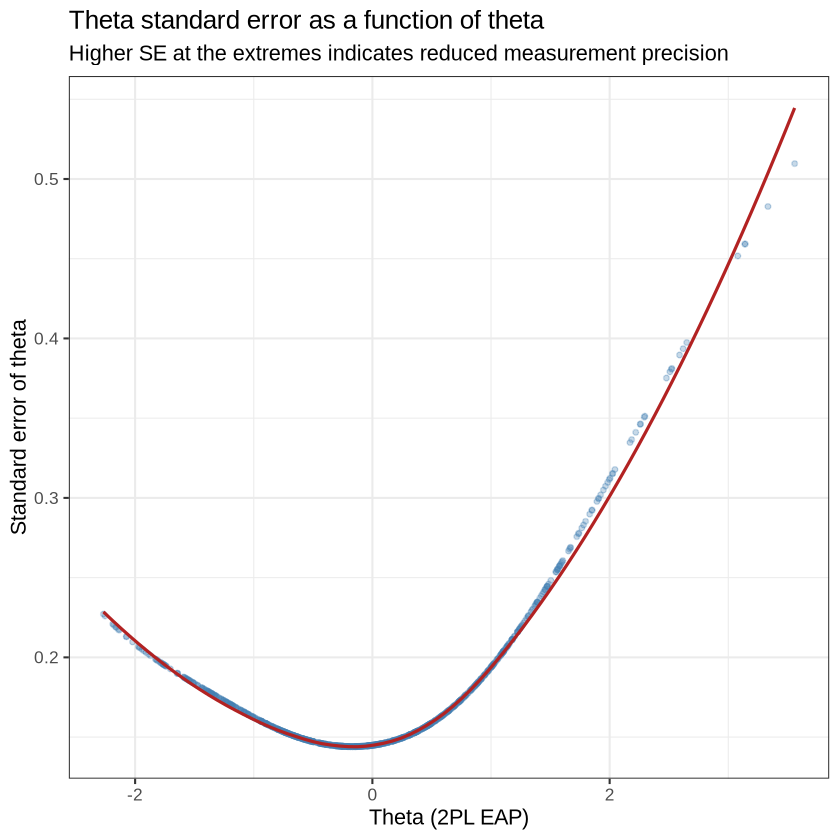

In [11]:
# Theta SE by extreme vs. non-extreme participants
theta_cut <- quantile(person_df$theta, c(0.05, 0.95), na.rm = TRUE)
person_df$theta_region <- ifelse(
  person_df$theta <= theta_cut[1], "Bottom 5%",
  ifelse(person_df$theta >= theta_cut[2], "Top 5%", "Middle 90%")
)
person_df$theta_region <- factor(person_df$theta_region,
                                 levels = c("Bottom 5%", "Middle 90%", "Top 5%"))

se_summary <- aggregate(irt06_theta_se ~ theta_region, data = person_df,
                        FUN = function(x) round(mean(x, na.rm = TRUE), 3))
cat("\u2500\u2500 Mean theta SE by region \u2500\u2500\n")
print(se_summary)

ggplot(person_df, aes(x = theta, y = irt06_theta_se)) +
  geom_point(alpha = 0.3, colour = "steelblue", size = 1.2) +
  geom_smooth(method = "loess", colour = "firebrick", linewidth = 0.9, se = FALSE) +
  labs(
    title    = "Theta standard error as a function of theta",
    subtitle = "Higher SE at the extremes indicates reduced measurement precision",
    x        = "Theta (2PL EAP)",
    y        = "Standard error of theta"
  ) +
  theme_bw(base_size = 13)

### Summary — Floor/ceiling effects and measurement precision

- **Observed scores** show negligible floor or ceiling effects: fewer than 0.2 % of participants sit at either extreme for hits, corrected ART, or the stronger-penalty score. The test covers the full ability range well.
- **Theta SE** follows the expected U-shaped pattern: lowest in the middle (mean SE = 0.164 for the middle 90 %), rising at both tails.
- The upper tail is noticeably worse: mean SE = 0.333 for the top 5 %, nearly twice the mid-range value. This reflects a shortage of hard items to discriminate among the highest-ability participants — a common limitation in population-normed tests.
- For all practical analyses, floor/ceiling effects are not a concern for the current sample.

### 8.1 (continued) — Theta across demographic groups

We examine whether estimated print exposure (theta) differs systematically by sex, humanities background, age group, and profession category. Group differences are assessed descriptively (boxplots) and with appropriate significance tests.

── Theta by sex ──
  sex   n mean_theta sd_theta
1   F 597      0.064    0.916
2   M 311     -0.126    1.094

Welch t-test: t(540.1) = 2.623, p = 0.0090


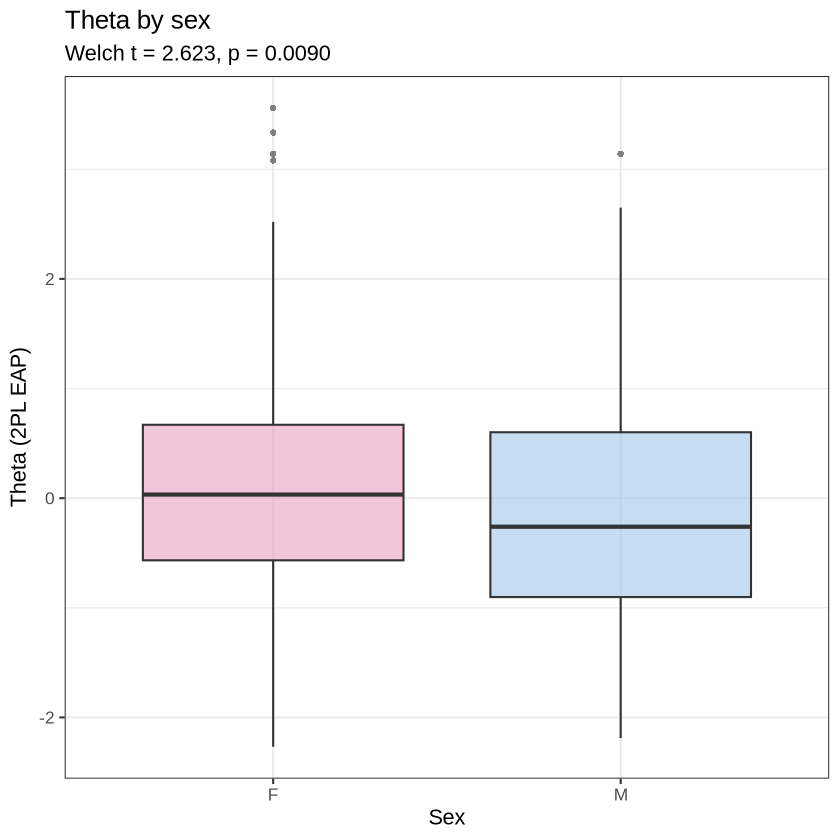

In [12]:
# Recode sex; keep only M/F (drop missing)
person_df$sex_clean <- ifelse(person_df$sex %in% c("M", "F"), person_df$sex, NA)

sex_df <- person_df[!is.na(person_df$sex_clean) & !is.na(person_df$theta), ]
sex_agg <- aggregate(theta ~ sex_clean, data = sex_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
sex_agg <- do.call(data.frame, sex_agg)
names(sex_agg) <- c("sex", "n", "mean_theta", "sd_theta")

t_sex <- t.test(theta ~ sex_clean, data = sex_df)

cat("\u2500\u2500 Theta by sex \u2500\u2500\n")
sex_agg_print <- sex_agg
sex_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(sex_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(sex_agg_print)
cat(sprintf("\nWelch t-test: t(%s) = %.3f, p = %.4f\n",
            format(round(t_sex$parameter, 1)),
            t_sex$statistic, t_sex$p.value))

ggplot(sex_df, aes(x = sex_clean, y = theta, fill = sex_clean)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_manual(values = c("F" = "#E8A0BF", "M" = "#A0C4E8"), guide = "none") +
  labs(
    title    = "Theta by sex",
    subtitle = sprintf("Welch t = %.3f, p = %.4f", t_sex$statistic, t_sex$p.value),
    x        = "Sex",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by humanities background ──
           group   n mean_theta sd_theta
1 Non-humanities 599     -0.132    0.956
2     Humanities 201      0.511    0.848

Welch t-test: t(383.9) = -8.998, p = 0.0000


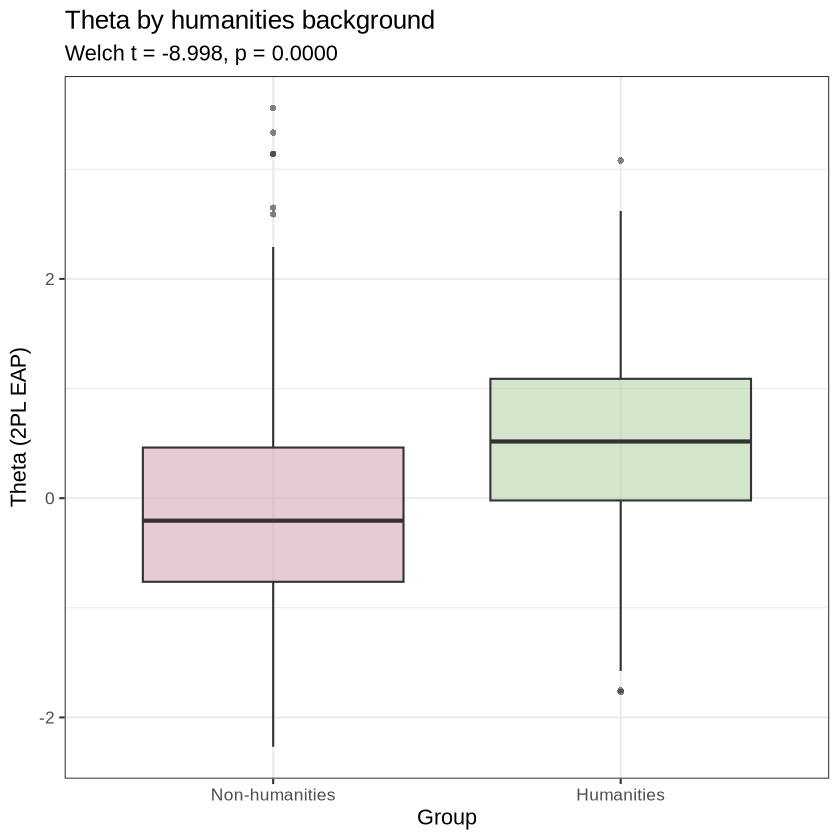

In [13]:
# humanities_or_not: '+' = humanities, '-' = non-humanities; others excluded
person_df$hum_clean <- ifelse(person_df$humanities_or_not %in% c("+", "-"),
                              person_df$humanities_or_not, NA)
hum_df <- person_df[!is.na(person_df$hum_clean) & !is.na(person_df$theta), ]
hum_df$hum_label <- ifelse(hum_df$hum_clean == "+", "Humanities", "Non-humanities")
hum_df$hum_label <- factor(hum_df$hum_label, levels = c("Non-humanities", "Humanities"))

hum_agg <- aggregate(theta ~ hum_label, data = hum_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
hum_agg <- do.call(data.frame, hum_agg)
names(hum_agg) <- c("group", "n", "mean_theta", "sd_theta")

t_hum <- t.test(theta ~ hum_label, data = hum_df)

cat("\u2500\u2500 Theta by humanities background \u2500\u2500\n")
hum_agg_print <- hum_agg
hum_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(hum_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(hum_agg_print)
cat(sprintf("\nWelch t-test: t(%s) = %.3f, p = %.4f\n",
            format(round(t_hum$parameter, 1)),
            t_hum$statistic, t_hum$p.value))

ggplot(hum_df, aes(x = hum_label, y = theta, fill = hum_label)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_manual(values = c("Humanities" = "#B5D5A8", "Non-humanities" = "#D5A8B5"),
                    guide = "none") +
  labs(
    title    = "Theta by humanities background",
    subtitle = sprintf("Welch t = %.3f, p = %.4f", t_hum$statistic, t_hum$p.value),
    x        = "Group",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by age group ──
  age_group   n mean_theta sd_theta
1       ≤25 365     -0.294    0.912
2     26-35 372      0.146    1.031
3     36-50 143      0.292    0.847
4       51+  28      0.388    0.932

One-way ANOVA:
             Df Sum Sq Mean Sq F value    Pr(>F)    
age_group     3  55.85 18.6181  20.466 7.764e-13 ***
Residuals   904 822.39  0.9097                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


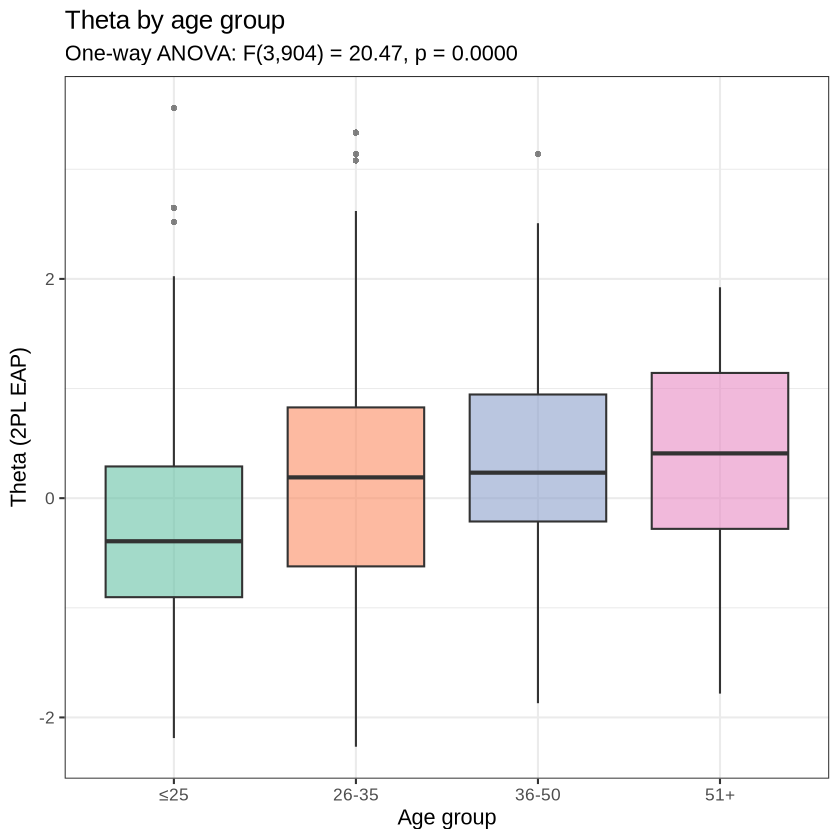

In [14]:
# Age groups
person_df$age_group <- cut(
  person_df$age,
  breaks = c(-Inf, 25, 35, 50, Inf),
  labels = c("\u226425", "26-35", "36-50", "51+"),
  right  = TRUE
)

age_df <- person_df[!is.na(person_df$age_group) & !is.na(person_df$theta), ]

age_agg <- aggregate(theta ~ age_group, data = age_df,
                     FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
age_agg <- do.call(data.frame, age_agg)
names(age_agg) <- c("age_group", "n", "mean_theta", "sd_theta")

aov_age <- aov(theta ~ age_group, data = age_df)
aov_summary <- summary(aov_age)[[1]]

cat("\u2500\u2500 Theta by age group \u2500\u2500\n")
age_agg_print <- age_agg
age_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(age_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(age_agg_print)
cat("\nOne-way ANOVA:\n")
print(aov_summary)

ggplot(age_df, aes(x = age_group, y = theta, fill = age_group)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  labs(
    title    = "Theta by age group",
    subtitle = sprintf("One-way ANOVA: F(%d,%d) = %.2f, p = %.4f",
                       aov_summary[["Df"]][1], aov_summary[["Df"]][2],
                       aov_summary[["F value"]][1], aov_summary[["Pr(>F)"]][1]),
    x        = "Age group",
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

── Theta by profession / education category ──
             profession   n mean_theta sd_theta
1 Science and Education 276      0.314    0.871
2      Service Industry 258     -0.052    0.988
3    IT and Engineering 143     -0.401    0.953
4       Art and Culture  74      0.256    0.918
5        Student/School  26     -0.686    0.609

Kruskal-Wallis: chi-squared = 82.186, df = 4, p = 0.0000


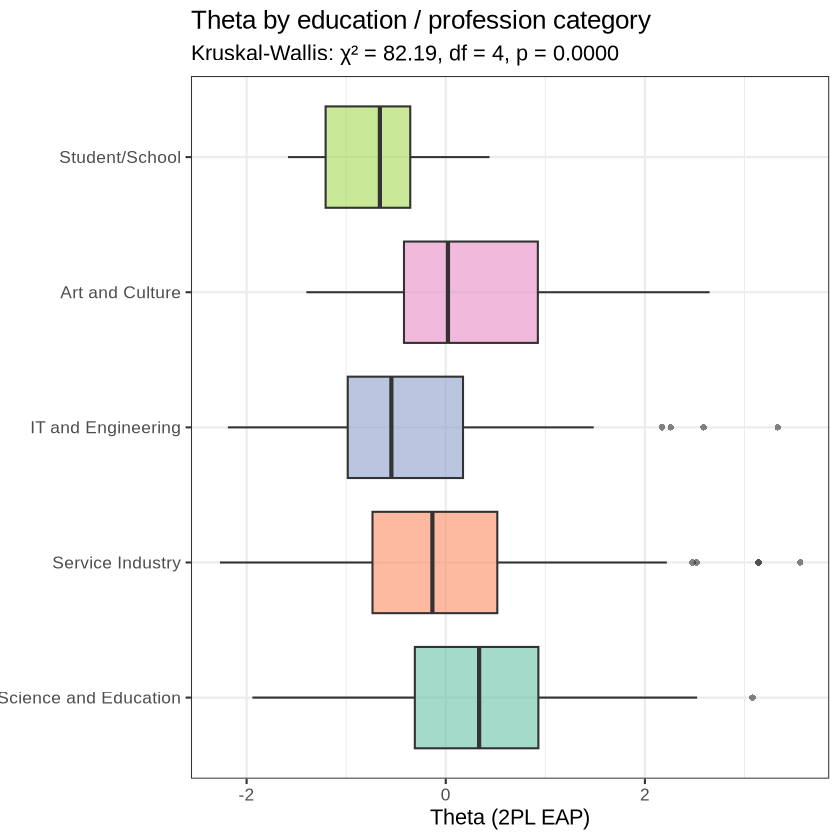

In [15]:
# education_and_profession — keep labelled categories, exclude Missing/Unknown
valid_profs <- c("Science and Education", "Service Industry", "IT and Engineering",
                 "Art and Culture", "Student/School")
prof_df <- person_df[
  person_df$education_and_profession %in% valid_profs & !is.na(person_df$theta), 
]
prof_df$education_and_profession <- factor(
  prof_df$education_and_profession,
  levels = valid_profs
)

prof_agg <- aggregate(theta ~ education_and_profession, data = prof_df,
                      FUN = function(x) c(n = length(x), mean = mean(x), sd = sd(x)))
prof_agg <- do.call(data.frame, prof_agg)
names(prof_agg) <- c("profession", "n", "mean_theta", "sd_theta")

kw_prof <- kruskal.test(theta ~ education_and_profession, data = prof_df)

cat("\u2500\u2500 Theta by profession / education category \u2500\u2500\n")
prof_agg_print <- prof_agg
prof_agg_print[, c("n", "mean_theta", "sd_theta")] <- round(prof_agg_print[, c("n", "mean_theta", "sd_theta")], 3)
print(prof_agg_print)
cat(sprintf("\nKruskal-Wallis: chi-squared = %.3f, df = %d, p = %.4f\n",
            kw_prof$statistic, kw_prof$parameter, kw_prof$p.value))

ggplot(prof_df, aes(x = education_and_profession, y = theta, fill = education_and_profession)) +
  geom_boxplot(alpha = 0.6, outlier.shape = 16, outlier.size = 1.5) +
  scale_fill_brewer(palette = "Set2", guide = "none") +
  coord_flip() +
  labs(
    title    = "Theta by education / profession category",
    subtitle = sprintf("Kruskal-Wallis: \u03c7\u00b2 = %.2f, df = %d, p = %.4f",
                       kw_prof$statistic, kw_prof$parameter, kw_prof$p.value),
    x        = NULL,
    y        = "Theta (2PL EAP)"
  ) +
  theme_bw(base_size = 13)

### Summary — Theta across demographic groups

**Sex** (Welch *t* = 2.62, *p* = .009): Women score modestly higher than men (mean θ: +0.06 vs. −0.13, Δ ≈ 0.19). The difference is statistically significant but small in practical terms (Cohen's *d* ≈ 0.2). The larger male SD (1.09 vs. 0.92) suggests more variability in print exposure among men.

**Humanities background** (Welch *t* = −9.00, *p* < .001): The largest group difference. Humanities-background participants outscore non-humanities by roughly 0.64 theta units (mean θ: +0.51 vs. −0.13). This is a strong, expected finding — familiarity with Russian literature is a direct component of humanities education.

**Age group** (one-way ANOVA: *F*(3, 904) = 20.47, *p* < .001): Theta increases monotonically with age — younger participants (≤25) score lowest (mean θ = −0.29), and the 51+ group scores highest (mean θ = +0.39). This likely reflects accumulated reading exposure over the lifespan rather than cohort effects.

**Profession / education** (Kruskal-Wallis: χ² = 82.19, df = 4, *p* < .001): Substantial variation across categories. Science & Education (0.31) and Art & Culture (0.26) score highest; IT & Engineering (−0.40) and Student/School (−0.69) score lowest. The student group's low score aligns with the age effect above. IT & Engineering being the lowest adult group is consistent with lower literary reading habits in technical fields.

> **Overall:** Demographics explain a meaningful share of theta variance. Humanities background is the strongest single predictor, followed by age and profession. Sex differences are real but small. These patterns are consistent with construct validity expectations for a literary author recognition test.

### 8.2 Score-type comparison

Following Moore & Gordon's (2015) argument that comparing score definitions strengthens the validity case, we report pairwise correlations among all four score types.

- **Hits**: raw author recognition count (no foil correction).
- **Corrected ART score**: hits − false alarms (standard 1:1 correction).
- **Stronger-penalty score**: hits − (104/98) × false alarms (proportional correction).
- **Theta**: 2PL EAP estimate; weights items by their discrimination parameter.

High mutual correlations indicate that the scores converge on the same underlying construct. Divergence reveals how foil penalties and IRT weighting change rank ordering.

In [16]:
score_mat <- person_df[, score_cols]
names(score_mat) <- c("Hits", "Corrected\nART", "Stronger\npenalty", "Theta")

cor_pearson  <- cor(score_mat, method = "pearson",  use = "complete.obs")
cor_spearman <- cor(score_mat, method = "spearman", use = "complete.obs")

cat("\u2500\u2500 Pearson correlations \u2500\u2500\n")
print(round(cor_pearson, 3))
cat("\n\u2500\u2500 Spearman correlations \u2500\u2500\n")
print(round(cor_spearman, 3))

── Pearson correlations ──
                   Hits Corrected\nART Stronger\npenalty Theta
Hits              1.000          0.968             0.964 0.983
Corrected\nART    0.968          1.000             1.000 0.958
Stronger\npenalty 0.964          1.000             1.000 0.955
Theta             0.983          0.958             0.955 1.000

── Spearman correlations ──
                   Hits Corrected\nART Stronger\npenalty Theta
Hits              1.000          0.969             0.965 0.994
Corrected\nART    0.969          1.000             1.000 0.972
Stronger\npenalty 0.965          1.000             1.000 0.968
Theta             0.994          0.972             0.968 1.000


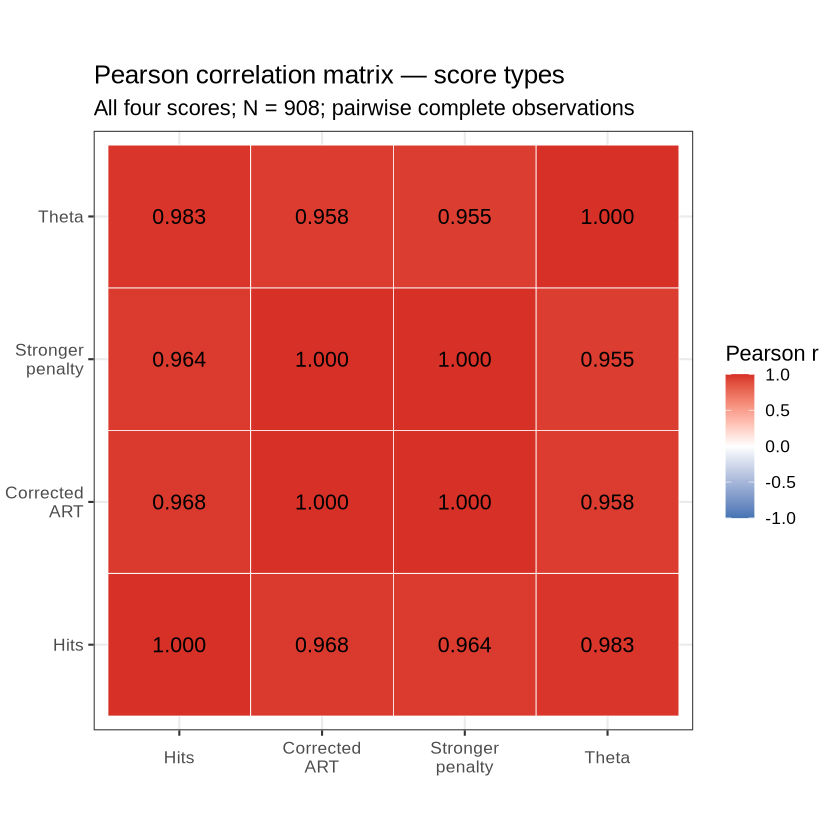

In [17]:
# Heatmap — Pearson
cor_long <- melt(cor_pearson)
names(cor_long) <- c("Var1", "Var2", "r")
cor_long$label <- sprintf("%.3f", cor_long$r)

ggplot(cor_long, aes(x = Var1, y = Var2, fill = r)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = label), size = 4.5) +
  scale_fill_gradient2(
    low = "#4575B4", mid = "white", high = "#D73027",
    midpoint = 0, limits = c(-1, 1), name = "Pearson r"
  ) +
  labs(
    title    = "Pearson correlation matrix — score types",
    subtitle = "All four scores; N = 908; pairwise complete observations",
    x        = NULL,
    y        = NULL
  ) +
  coord_fixed() +
  theme_bw(base_size = 13) +
  theme(axis.text.x = element_text(angle = 0, vjust = 0.5))

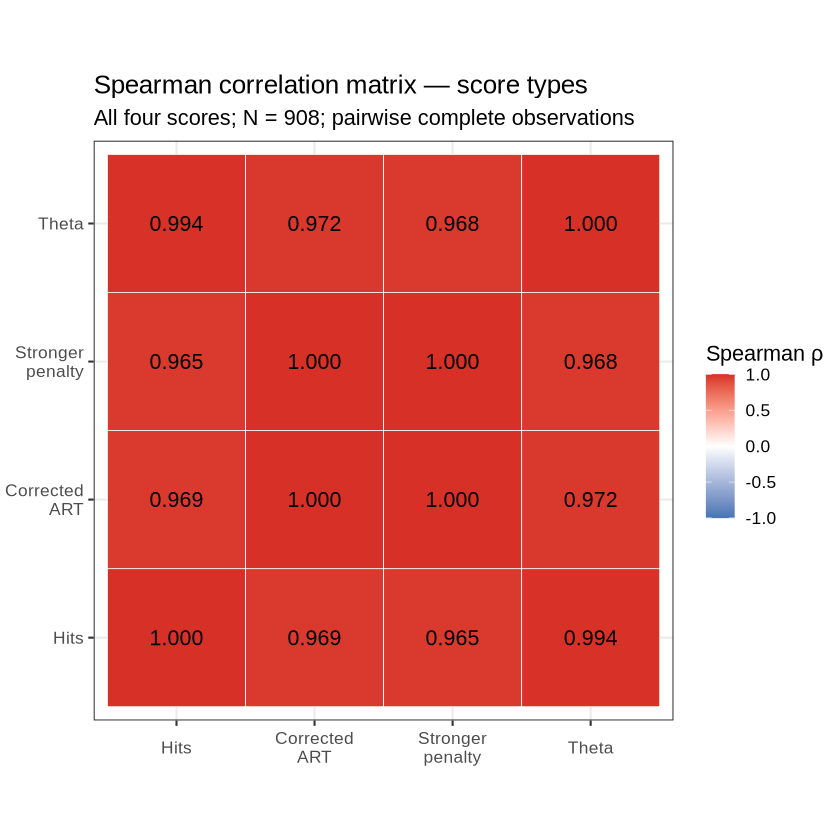

In [18]:
# Heatmap — Spearman
cor_long_sp <- melt(cor_spearman)
names(cor_long_sp) <- c("Var1", "Var2", "r")
cor_long_sp$label <- sprintf("%.3f", cor_long_sp$r)

ggplot(cor_long_sp, aes(x = Var1, y = Var2, fill = r)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = label), size = 4.5) +
  scale_fill_gradient2(
    low = "#4575B4", mid = "white", high = "#D73027",
    midpoint = 0, limits = c(-1, 1), name = "Spearman \u03c1"
  ) +
  labs(
    title    = "Spearman correlation matrix — score types",
    subtitle = "All four scores; N = 908; pairwise complete observations",
    x        = NULL,
    y        = NULL
  ) +
  coord_fixed() +
  theme_bw(base_size = 13) +
  theme(axis.text.x = element_text(angle = 0, vjust = 0.5))

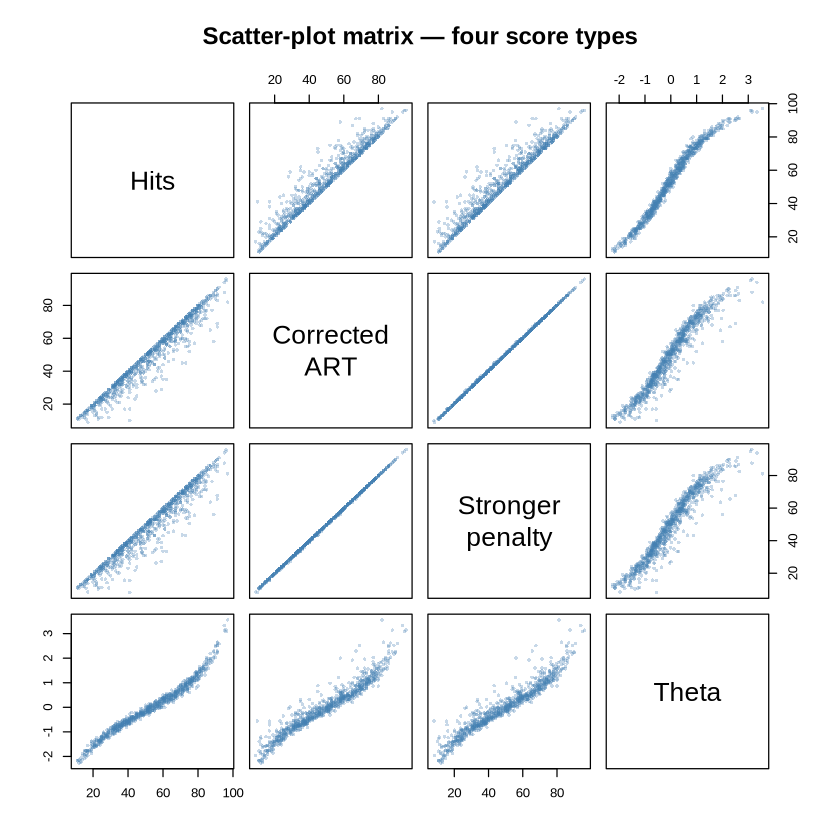

In [19]:
# Scatter-plot matrix for a fuller picture
pairs(
  score_mat,
  labels = c("Hits", "Corrected\nART", "Stronger\npenalty", "Theta"),
  pch    = 16,
  col    = adjustcolor("steelblue", alpha.f = 0.3),
  cex    = 0.6,
  main   = "Scatter-plot matrix — four score types"
)

### Summary — Score-type comparison (§8.2)

All four scores are extremely highly intercorrelated (all Pearson *r* ≥ 0.955, all Spearman ρ ≥ 0.965), confirming they measure the same underlying construct.

| Pair | Pearson *r* | Spearman ρ |
|---|---|---|
| Hits ↔ Corrected ART | 0.968 | 0.969 |
| Hits ↔ Stronger penalty | 0.964 | 0.965 |
| Corrected ART ↔ Stronger penalty | 1.000 | 1.000 |
| Hits ↔ Theta | 0.983 | 0.994 |
| Corrected ART ↔ Theta | 0.958 | 0.972 |
| Stronger penalty ↔ Theta | 0.955 | 0.968 |

**Key observations:**

- **Corrected ART and Stronger penalty are effectively identical** (*r* = 1.000) because the foil-to-author ratio is close to 1 (1.06), making the extra penalty weight negligible. Using one over the other makes no practical difference.
- **Hits correlates more strongly with Theta** (Pearson *r* = 0.983, Spearman ρ = 0.994) than the corrected scores do. This is because the IRT model already accounts for false alarms implicitly through item difficulty calibration — adding an explicit penalty on top does not improve alignment.
- **All scatter plots show clean, monotone relationships** with only mild nonlinearity at the upper extreme (theta compresses the scale for the highest scorers, as seen earlier).
- **Conclusion:** any of the four scores would yield near-identical research conclusions. Theta is preferred for its psychometric properties (item-difficulty weighting, person-level SE); corrected ART score is the recommended simple alternative for reporting descriptive statistics on a familiar, interpretable scale.

## Export

The enriched person-level dataset is written to `data/stepwise_cleaned_versions/07_person_scoring/`.

In [20]:
OUTPUT_DIR <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                        "07_person_scoring")
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

export_cols <- c(
  "participant_id",
  # IRT scores
  "irt06_theta", "irt06_theta_se",
  # Observed scores
  "hits", "false_alarms",
  "corrected_art_score", "stronger_penalty_score",
  # Demographics
  "age", "sex", "humanities_or_not", "education_and_profession",
  # Derived
  "age_group", "sex_clean", "hum_clean"
)
export_cols_present <- intersect(export_cols, names(person_df))

out_df  <- person_df[, export_cols_present]
out_file <- file.path(OUTPUT_DIR,
                      "ART_pretest_(for Castano)_EN__person_scores.csv")
write.csv(out_df, file = out_file, row.names = FALSE)

cat("\u2500\u2500 Export complete \u2500\u2500\n")
cat(sprintf("  Rows    : %d\n",  nrow(out_df)))
cat(sprintf("  Columns : %d\n",  ncol(out_df)))
cat(sprintf("  File    : %s\n",  basename(out_file)))
cat(sprintf("  Path    : %s\n",  out_file))

── Export complete ──
  Rows    : 908
  Columns : 14
  File    : ART_pretest_(for Castano)_EN__person_scores.csv
  Path    : /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/07_person_scoring/ART_pretest_(for Castano)_EN__person_scores.csv
